In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

DATA_PATH = "/content/mosfet_data/extracted"
N_BUCKETS = 300
WINDOW = 15

In [ ]:
!wget -q "https://phm-datasets.s3.amazonaws.com/NASA/13.+MOSFET+Thermal+Overstress+Aging.zip" -O mosfet_data.zip
!unzip -q mosfet_data.zip -d /content/mosfet_data
!unzip -q "/content/mosfet_data/13. MOSFET Thermal Overstress Aging/MOSFET_Thermal_Overstress_Aging_v0.zip" -d /content/mosfet_data/extracted
!find /content/mosfet_data/extracted -iname "*.mat" | wc -l

106


In [ ]:
mat_files = glob.glob(os.path.join(DATA_PATH, "**", "*.mat"), recursive=True)
mat_files = [f for f in mat_files if "error setting up" not in f and "rampup" not in f.lower()]

print("MAT files after exclusions:", len(mat_files))

if len(mat_files) == 0:
    raise FileNotFoundError("No .mat files found after filtering. Check DATA_PATH and the download step above.")

MAT files after exclusions: 104


In [ ]:
def load_mat_file(filepath):
    mat = sio.loadmat(filepath)
    measurement = mat["measurement"][0, 0]

    if "steadyState" not in measurement.dtype.names:
        raise ValueError(f"No 'steadyState' field found in {filepath}")

    steady = measurement["steadyState"]  # shape (1, N) -- N snapshots over the test
    n_records = steady.shape[1]

    times = []
    signals = []

    for i in range(n_records):
        record = steady[0, i]
        td = record["timeDomain"][0, 0]

        t = record["timeEpoch"][0, 0]
        vds = td["drainSourceVoltage"][0, 0]
        id_ = td["drainCurrent"][0, 0]

        if abs(id_) < 1e-12:
            continue  # avoid divide-by-zero on a near-zero current reading

        rds = vds / id_  # Ohm's law: resistance = voltage / current
        times.append(t)
        signals.append(rds)

    df = pd.DataFrame({"time": times, "signal": signals})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df.sort_values("time").drop_duplicates("time").reset_index(drop=True)

    return df

In [ ]:
def resample_signal(df):
    if len(df) < 30:
        return df.copy()

    buckets = min(N_BUCKETS, len(df))
    bins = np.linspace(df["time"].min(), df["time"].max(), buckets + 1)

    temp = df.copy()
    temp["bucket"] = pd.cut(temp["time"], bins=bins, labels=False, include_lowest=True)

    result = (
        temp.groupby("bucket", observed=True)
        .agg({"time": "mean", "signal": "mean"})
        .reset_index(drop=True)
    )
    return result


def add_features(df):
    df = df.copy()
    df["rolling_mean"] = df["signal"].rolling(WINDOW, min_periods=3).mean()
    df["rolling_std"] = df["signal"].rolling(WINDOW, min_periods=3).std()
    df["diff"] = df["signal"].diff()
    df["relative_change"] = (df["signal"] - df["signal"].iloc[0]) / (abs(df["signal"].iloc[0]) + 1e-12)
    df["drift_rate"] = df["signal"].diff() / (df["time"].diff() + 1e-12)

    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return df

In [ ]:
components = {}

for filepath in mat_files:
    component_id = os.path.splitext(os.path.basename(filepath))[0]

    try:
        df = load_mat_file(filepath)
        df = resample_signal(df)
        df = add_features(df)
        components[component_id] = df
        print(component_id, "processed:", len(df), "points")

    except Exception as e:
        print("Skipped", component_id, ":", e)

if len(components) == 0:
    raise ValueError("No component files could be processed.")

print(f"\nTotal devices processed: {len(components)}")

Test_27_run_3 processed: 298 points
Test_9_run_6 processed: 298 points
Test_2_run_1 processed: 298 points
Test_11_run_5 processed: 298 points
Test_20_run_2 processed: 298 points
Test_20_run_1 processed: 298 points
Test_11_run_6 processed: 298 points
Test_13_run_3 processed: 298 points
Test_9_run_3 processed: 298 points
Test_28_run_1 processed: 298 points
Test_9_run_7 processed: 298 points
Test_5_run_1 processed: 298 points
Test_23_run_1 processed: 298 points
Test_8_run_6 processed: 298 points
Test_25_run_4 processed: 27 points
Test_4_run_2 processed: 298 points
Test_12_run_3 processed: 298 points
Test_37_run_1 processed: 298 points
Test_10_run_4 processed: 298 points
Test_1_run_1 processed: 298 points
Test_18_run_1 processed: 298 points
Test_19_run_1 processed: 298 points
Test_2_run_3 processed: 298 points
Test_13_run_5 processed: 298 points
Test_14_run_5 processed: 298 points
Test_5_run_2 processed: 206 points
Test_40_run_1 processed: 298 points
Test_8_run_5 processed: 298 points
Test

In [ ]:
def summarize_component(component_id, df):
    first = df["signal"].iloc[0]
    last = df["signal"].iloc[-1]
    slope = np.polyfit(df["time"], df["signal"], 1)[0]
    change = ((last - first) / (abs(first) + 1e-12)) * 100
    drift = df["drift_rate"].abs().median()

    return {
        "component": component_id,
        "initial_value": first,
        "final_value": last,
        "change_percent": change,
        "slope": slope,
        "drift_rate": drift,
        "volatility": df["signal"].std(),
    }


summary = pd.DataFrame(
    [summarize_component(cid, df) for cid, df in components.items()]
)

In [ ]:
feature_cols = ["change_percent", "slope", "drift_rate", "volatility"]

X = summary[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model_a = IsolationForest(n_estimators=200, contamination="auto", random_state=42)

summary["anomaly"] = model_a.fit_predict(X_scaled)
summary["anomaly_score"] = -model_a.score_samples(X_scaled)

In [ ]:
summary["anomaly_percentile"] = summary["anomaly_score"].rank(pct=True) * 100
summary["drift_percentile"] = summary["change_percent"].abs().rank(pct=True) * 100
summary["risk_score"] = 0.55 * summary["anomaly_percentile"] + 0.45 * summary["drift_percentile"]

def risk_label(score):
    if score >= 75:
        return "CRITICAL"
    if score >= 50:
        return "WATCH"
    return "NORMAL"

summary["status"] = summary["risk_score"].apply(risk_label)

In [ ]:
def explanation(row):
    reasons = []
    if row["anomaly"] == -1:
        reasons.append("unusual behavior compared with other components")
    if row["drift_percentile"] >= 75:
        reasons.append("high drift from its initial value")
    if row["volatility"] >= summary["volatility"].quantile(0.75):
        reasons.append("higher-than-usual signal variation")
    if len(reasons) == 0:
        return "behavior is within the normal population range"
    return "; ".join(reasons)

summary["explanation"] = summary.apply(explanation, axis=1)

summary = summary.sort_values("risk_score", ascending=False)

print("SCREENING SUMMARY")
print("Total:", len(summary))
print("Normal:", (summary["status"] == "NORMAL").sum())
print("Watch:", (summary["status"] == "WATCH").sum())
print("Critical:", (summary["status"] == "CRITICAL").sum())

summary

SCREENING SUMMARY
Total: 104
Normal: 55
Watch: 31
Critical: 18


,component,initial_value,final_value,change_percent,slope,drift_rate,volatility,anomaly,anomaly_score,anomaly_percentile,drift_percentile,risk_score,status,explanation
85,Test_10_run_1,2.490888,21.941544,780.872391,420.663857,41038.949483,6.680574,-1,0.684817,96.153846,100.000000,97.884615,CRITICAL,unusual behavior compared with other component...
19,Test_1_run_1,0.793425,1.784308,124.886699,-11906.298198,2264.944358,46.030123,-1,0.587663,94.230769,99.038462,96.394231,CRITICAL,unusual behavior compared with other component...
35,Test_1_run_2,1.375647,0.058496,-95.747722,4519.946717,668648.839365,88.010841,-1,0.751166,100.000000,91.346154,96.105769,CRITICAL,unusual behavior compared with other component...
22,Test_2_run_3,116.740114,0.073534,-99.937010,-8836.085765,4909.583830,53.048926,-1,0.511547,92.307692,96.153846,94.038462,CRITICAL,unusual behavior compared with other component...
73,Test_38_run_1,108.918414,232.217558,113.203213,1058.107386,1888.097493,70.669600,-1,0.505447,89.423077,98.076923,93.317308,CRITICAL,unusual behavior compared with other component...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Test_10_run_5,51.673806,34.432625,-33.365416,-25.147239,1816.027657,1.736191,1,0.345438,8.653846,24.038462,15.576923,NORMAL,behavior is within the normal population range
13,Test_8_run_6,91.862669,60.207352,-34.459392,-12.848786,2887.120644,3.000570,1,0.342424,2.884615,26.923077,13.701923,NORMAL,behavior is within the normal population range
41,Test_10_run_6,47.663205,33.489345,-29.737531,-10.714729,1666.732575,1.561833,1,0.345776,9.615385,18.269231,13.509615,NORMAL,behavior is within the normal population range
76,Test_34_run_3,96.587771,63.936333,-33.804940,-46.348509,1675.490185,7.824083,1,0.341651,1.923077,25.000000,12.307692,NORMAL,behavior is within the normal population range


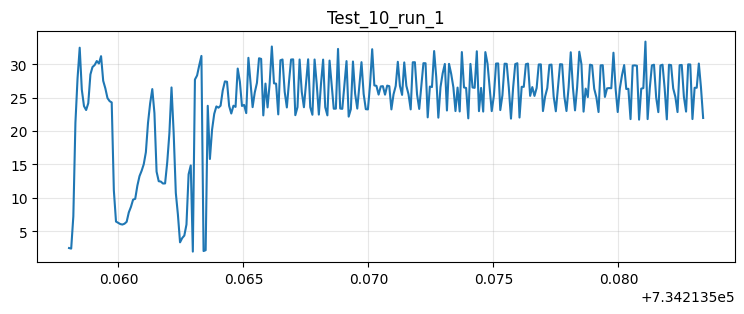

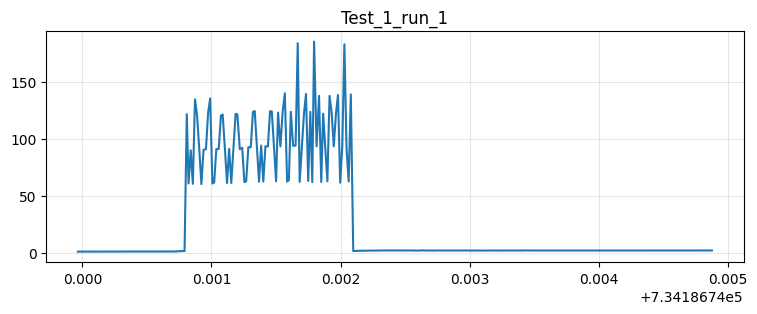

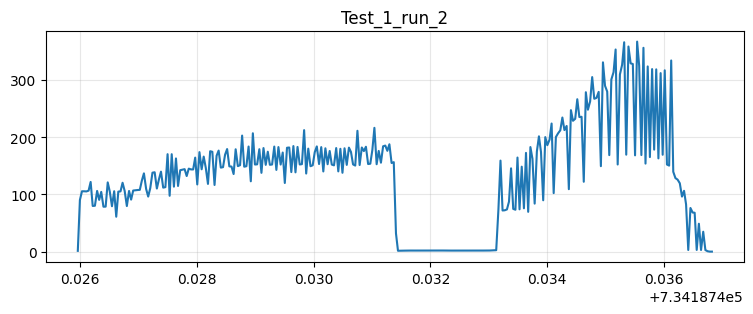

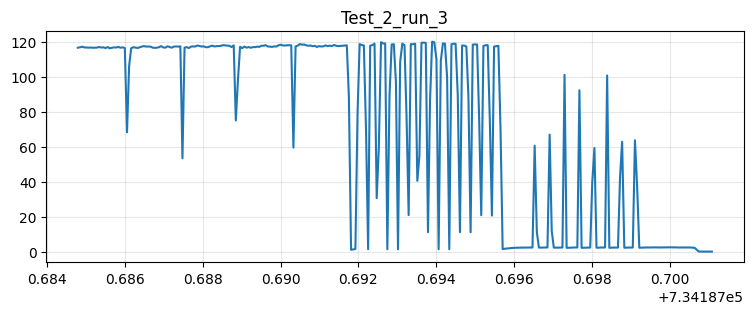

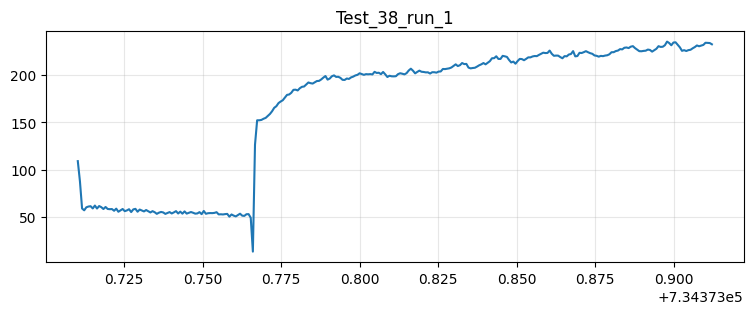

In [ ]:
# Plot the top 5 highest-risk devices' actual curves -- always eyeball these
# before trusting the summary numbers alone. A large "change_percent" can be
# driven by a single noisy endpoint rather than a real trend.
for comp_id in summary.head(5)["component"]:
    df = components[comp_id]
    plt.figure(figsize=(9, 3))
    plt.plot(df["time"], df["signal"])
    plt.title(comp_id)
    plt.grid(alpha=0.3)
    plt.show()

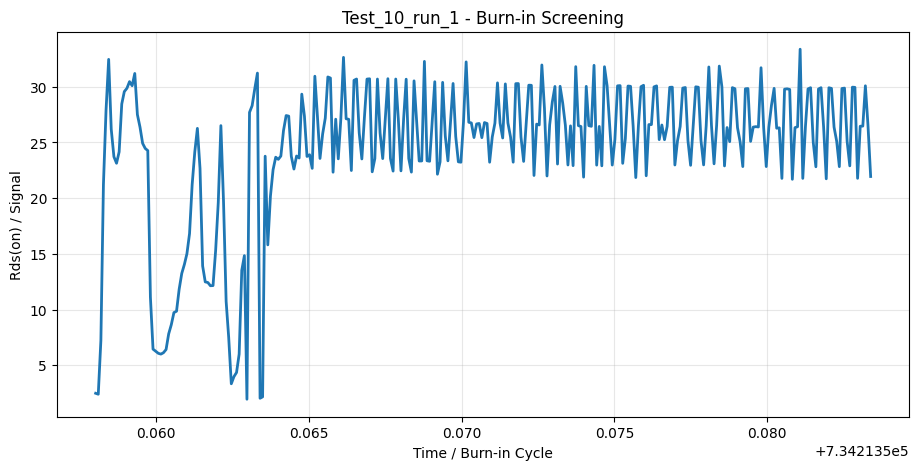

MOST SUSPICIOUS COMPONENT
Component: Test_10_run_1
Status: CRITICAL
Risk score: 97.88
Change: 780.87 %
Reason: unusual behavior compared with other components; high drift from its initial value


In [ ]:
top = summary.iloc[0]
component_id = top["component"]
df = components[component_id]

plt.figure(figsize=(11, 5))
plt.plot(df["time"], df["signal"], linewidth=2)
plt.xlabel("Time / Burn-in Cycle")
plt.ylabel("Rds(on) / Signal")
plt.title(f"{component_id} - Burn-in Screening")
plt.grid(alpha=0.3)
plt.show()

print("MOST SUSPICIOUS COMPONENT")
print("Component:", top["component"])
print("Status:", top["status"])
print("Risk score:", round(top["risk_score"], 2))
print("Change:", round(top["change_percent"], 2), "%")
print("Reason:", top["explanation"])

In [ ]:
summary.to_csv("/content/module_a_results.csv", index=False)
print("Module A results saved to /content/module_a_results.csv")

Module A results saved to /content/module_a_results.csv


Module B

In [ ]:
EARLY_FRACTION = 0.2   # first 20% of the resampled curve = "early readings"
LATE_FRACTION = 0.1    # last 10% = "final behavior" (a robust stand-in for the 168h value)

def early_late_features(df):
    n = len(df)
    n_early = max(3, int(n * EARLY_FRACTION))
    n_late = max(3, int(n * LATE_FRACTION))

    early = df.iloc[:n_early]
    late = df.iloc[-n_late:]

    early_mean = early["signal"].mean()
    early_slope = np.polyfit(early["time"], early["signal"], 1)[0]
    early_volatility = early["signal"].std()
    target_late_value = late["signal"].mean()

    return early_mean, early_slope, early_volatility, target_late_value

rows = []
for comp_id, df in components.items():
    if len(df) < 10:
        continue
    early_mean, early_slope, early_volatility, target = early_late_features(df)
    rows.append({
        "component": comp_id,
        "early_mean": early_mean,
        "early_slope": early_slope,
        "early_volatility": early_volatility,
        "target_late_value": target,
    })

drift_data = pd.DataFrame(rows)
print(drift_data.shape)
drift_data.head()

(104, 5)


,component,early_mean,early_slope,early_volatility,target_late_value
0,Test_27_run_3,121.546702,-39614.658935,49.930295,64.379554
1,Test_9_run_6,34.115928,13.496549,1.342468,33.293845
2,Test_2_run_1,115.040940,-1644.391972,13.951996,90.137000
3,Test_11_run_5,32.510830,-139.568359,2.787919,31.655214
4,Test_20_run_2,14.451795,-1004.718554,14.796365,2.402943


In [ ]:
feature_cols_b = ["early_mean", "early_slope", "early_volatility"]

X_b = drift_data[feature_cols_b]
y_b = drift_data["target_late_value"]

X_train, X_test, y_train, y_test = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

model_b = LinearRegression()
model_b.fit(X_train, y_train)

y_pred = model_b.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Module B MAE on held-out test set: {mae:.3f}")

Module B MAE on held-out test set: 37.006


In [ ]:
print("Target value stats:\n", y_test.describe())

baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))
print("Naive baseline MAE (always predict train mean):", baseline_mae)

no_drift_mae = mean_absolute_error(y_test, X_test["early_mean"])
print("'No drift' baseline MAE (predict early_mean unchanged):", no_drift_mae)

Target value stats:
 count     21.000000
mean      52.722757
std       59.442828
min        2.402943
25%       27.167969
50%       33.225413
75%       64.379554
max      227.048251
Name: target_late_value, dtype: float64
Naive baseline MAE (always predict train mean): 39.31652831303117
'No drift' baseline MAE (predict early_mean unchanged): 45.60235504269347


In [ ]:
drift_data = drift_data.merge(summary[["component", "status"]], on="component", how="left")

drift_data["actual_change"] = drift_data["target_late_value"] - drift_data["early_mean"]

normal_changes = drift_data.loc[drift_data["status"] == "NORMAL", "actual_change"]
safety_change = normal_changes.quantile(0.95)
print("Safety change threshold (95th percentile of NORMAL devices):", safety_change)

drift_data["predicted_target"] = model_b.predict(drift_data[feature_cols_b])
drift_data["predicted_change"] = drift_data["predicted_target"] - drift_data["early_mean"]
drift_data["early_reject_flag"] = drift_data["predicted_change"] > safety_change

print(drift_data["early_reject_flag"].value_counts())

Safety change threshold (95th percentile of NORMAL devices): 8.682364254721907
early_reject_flag
False    83
True     21
Name: count, dtype: int64


In [ ]:
cross_tab = drift_data.groupby(["status", "early_reject_flag"]).size().unstack(fill_value=0)
print(cross_tab)

new_catches = drift_data[(drift_data["early_reject_flag"]) & (drift_data["status"] == "NORMAL")]
print("\nDevices Module B flags but Module A called NORMAL:")
print(new_catches[["component", "early_mean", "predicted_change", "status"]])

early_reject_flag  False  True 
status                         
CRITICAL              16      2
NORMAL                40     15
WATCH                 27      4

Devices Module B flags but Module A called NORMAL:
        component  early_mean  predicted_change  status
1    Test_9_run_6   34.115928         12.505241  NORMAL
3   Test_11_run_5   32.510830         11.938181  NORMAL
6   Test_11_run_6   31.937526         12.813769  NORMAL
10   Test_9_run_7   33.950186         12.956444  NORMAL
29  Test_31_run_1   15.901827         16.290534  NORMAL
41  Test_10_run_6   35.603845         10.900208  NORMAL
48  Test_27_run_4   17.722812         13.058854  NORMAL
49  Test_14_run_6   41.649321          8.778083  NORMAL
57  Test_10_run_5   37.153778         10.641808  NORMAL
75  Test_33_run_1    8.534437         21.130992  NORMAL
79   Test_9_run_5   35.064459         11.863235  NORMAL
82  Test_27_run_5   17.147145         13.504599  NORMAL
93  Test_11_run_7   33.963684         11.846528  NORMAL
95  

In [ ]:
drift_data.to_csv("/content/module_b_results.csv", index=False)
print("Module B results saved to /content/module_b_results.csv")

Module B results saved to /content/module_b_results.csv


In [ ]:
curve_rows = []
for cid, df in components.items():
    for t, s in zip(df["time"], df["signal"]):
        curve_rows.append({"component": cid, "time": t, "signal": s})

all_curves = pd.DataFrame(curve_rows)
all_curves.to_csv("/content/all_curves.csv", index=False)
print(f"Curve data saved to /content/all_curves.csv -- {len(all_curves)} rows "
      f"across {all_curves['component'].nunique()} devices")

Curve data saved to /content/all_curves.csv -- 30578 rows across 104 devices
